In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from pprint import pformat

from hloc import (
    extract_features,
    match_features,
    pairs_from_covisibility,
    pairs_from_retrieval,
)
from hloc import colmap_from_nvm, triangulation, localize_sfm, visualization

# Pipeline for outdoor day-night visual localization

## Setup
Here we declare the paths to the dataset, the reconstruction and localization outputs, and we choose the feature extractor and the matcher. You only need to download the [Aachen Day-Night dataset](https://www.visuallocalization.net/datasets/) and put it in `datasets/aachen/`, or change the path.

In [2]:
dataset = Path("datasets/aachen_v1_1/")  # change this if your dataset is somewhere else
images = dataset / "images_upright/"

outputs = Path("outputs/aachen/")  # where everything will be saved
sfm_pairs = outputs / "pairs-db-covis20.txt"  # top 20 most covisible in SIFT model
loc_pairs = outputs / "pairs-query-netvlad20.txt"  # top 20 retrieved by NetVLAD
reference_sfm = outputs / "sfm_superpoint+superglue"  # the SfM model we will build
results = outputs / "Aachen_hloc_superpoint+superglue_netvlad20.txt"  # the result file

# list the standard configurations available
print(f"Configs for feature extractors:\n{pformat(extract_features.confs)}")
print(f"Configs for feature matchers:\n{pformat(match_features.confs)}")

Configs for feature extractors:
{'aliked-n16': {'model': {'model_name': 'aliked-n16', 'name': 'aliked'},
                'output': 'feats-aliked-n16',
                'preprocessing': {'grayscale': False, 'resize_max': 1024}},
 'd2net-ss': {'model': {'multiscale': False, 'name': 'd2net'},
              'output': 'feats-d2net-ss',
              'preprocessing': {'grayscale': False, 'resize_max': 1600}},
 'dir': {'model': {'name': 'dir'},
         'output': 'global-feats-dir',
         'preprocessing': {'resize_max': 1024}},
 'disk': {'model': {'max_keypoints': 5000, 'name': 'disk'},
          'output': 'feats-disk',
          'preprocessing': {'grayscale': False, 'resize_max': 1600}},
 'eigenplaces': {'model': {'name': 'eigenplaces'},
                 'output': 'global-feats-eigenplaces',
                 'preprocessing': {'resize_max': 1024}},
 'netvlad': {'model': {'name': 'netvlad'},
             'output': 'global-feats-netvlad',
             'preprocessing': {'resize_max': 1024}},
 

In [3]:
# pick one of the configurations for image retrieval, local feature extraction, and matching
# you can also simply write your own here!
retrieval_conf = extract_features.confs["eigenplaces"]
feature_conf = extract_features.confs["superpoint_aachen"]
matcher_conf = match_features.confs["superglue"]

## Extract local features for database and query images

In [4]:
features = extract_features.main(feature_conf, images, outputs)

[2024/12/21 17:52:47 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-r1024',
 'preprocessing': {'grayscale': True, 'resize_max': 1024}}
[2024/12/21 17:52:47 hloc INFO] Found 7890 images in root datasets/aachen_v1_1/images_upright.


Loaded SuperPoint model


/home/shubham/Downloads/unknot_codebase/Hierarchical-Localization/hloc/extractors/../../third_party/SuperGluePretrainedNetwork/models/superpoint.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to thi

In [5]:
feature

PosixPath('outputs/aachen/feats-superpoint-n4096-r1024.h5')

The function returns the path of the file in which all the extracted features are stored.

## Generate pairs for the SfM reconstruction
Instead of matching all database images exhaustively, we exploit the existing SIFT model to find which image pairs are the most covisible. We first convert the SIFT model from the NVM to the COLMAP format, and then do a covisiblity search, selecting the top 20 most covisibile neighbors for each image.

In [5]:
# colmap_from_nvm.main(
#     dataset / "3D-models/aachen_cvpr2018_db.nvm",
#     dataset / "3D-models/database_intrinsics.txt",
#     dataset / "aachen.db",
#     outputs / "sfm_sift",
# )
######Shubham: Already exists!!

pairs_from_covisibility.main(outputs / "sfm_sift", sfm_pairs, num_matched=20)

[2024/12/21 18:01:55 hloc INFO] Reading the COLMAP model...
[2024/12/21 18:02:18 hloc INFO] Extracting image pairs from covisibility info...
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 6697/6697 [00:49<00:00, 135.80it/s]
[2024/12/21 18:03:07 hloc INFO] Found 133066 pairs.


## Match the database images

In [6]:
sfm_matches = match_features.main(
    matcher_conf, sfm_pairs, feature_conf["output"], outputs
)

[2024/12/21 18:03:22 hloc INFO] Matching local features with configuration:
{'model': {'name': 'superglue',
           'sinkhorn_iterations': 50,
           'weights': 'outdoor'},
 'output': 'matches-superglue'}


Loaded SuperGlue model ("outdoor" weights)


/home/shubham/Downloads/unknot_codebase/Hierarchical-Localization/hloc/extractors/../../third_party/SuperGluePretrainedNetwork/models/superglue.py:226: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this

The function returns the path of the file in which all the computed matches are stored.

## Triangulate a new SfM model from the given poses
We triangulate the sparse 3D pointcloud given the matches and the reference poses stored in the SIFT COLMAP model.

In [11]:
###Shubham: Features already computed
features = Path("outputs/aachen/feats-superpoint-n4096-r1024.h5")
sfm_matches = Path("outputs/aachen/feats-superpoint-n4096-r1024_matches-superglue_pairs-db-covis20.h5")

In [ ]:
reconstruction = triangulation.main(
    reference_sfm, outputs / "sfm_sift", images, sfm_pairs, features, sfm_matches
)

## Find image pairs via image retrieval
We extract global descriptors with NetVLAD and find for each image the $k$ most similar ones. A larger $k$ improves the robustness of the localization for difficult queries but makes the matching more expensive. Using $k{=}10{-}20$ is generally a good tradeoff but $k{=}50$ gives the best results for the Aachen Day-Night dataset.

In [4]:
global_descriptors = extract_features.main(retrieval_conf, images, outputs)
pairs_from_retrieval.main(
    global_descriptors, loc_pairs, num_matched=20, db_prefix="db", query_prefix="query"
)

[2025/01/01 18:26:30 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'eigenplaces'},
 'output': 'global-feats-eigenplaces',
 'preprocessing': {'resize_max': 1024}}
[2025/01/01 18:26:30 hloc INFO] Found 7890 images in root datasets/aachen_v1_1/images_upright.
/home/shubham/miniconda3/envs/hloc/lib/python3.11/site-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/gmberton/E

Returning EigenPlaces model with backbone: ResNet101 with features dimension 2048


Using cache found in /home/shubham/.cache/torch/hub/gmberton_cosplace_main


Returning CosPlace model with backbone: ResNet101 with features dimension 512


Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /home/shubham/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 171M/171M [00:02<00:00, 68.0MB/s]
Downloading: "https://github.com/gmberton/CosPlace/releases/download/v1.0/ResNet101_512_cosplace.pth" to /home/shubham/.cache/torch/hub/checkpoints/ResNet101_512_cosplace.pth
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 167M/167M [00:02<00:00, 60.2MB/s]
Downloading: "https://github.com/gmberton/EigenPlaces/releases/download/v1.0/ResNet101_2048_eigenplaces.pth" to /home/shubham/.cache/torch/hub/checkpoints/ResNet101_2048_eigenplaces.pth
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 179M/179M [00:03<00:00, 51.9MB/s]
  3%|██▊                       

KeyboardInterrupt: 

## Match the query images

In [4]:
### Shubham: already computed
loc_pairs = "outputs/aachen/pairs-query-netvlad20.txt"

In [9]:
loc_matches = match_features.main(
    matcher_conf, loc_pairs, feature_conf["output"], outputs
)

[2024/12/22 11:04:16 hloc INFO] Matching local features with configuration:
{'model': {'name': 'superglue',
           'sinkhorn_iterations': 50,
           'weights': 'outdoor'},
 'output': 'matches-superglue'}


Loaded SuperGlue model ("outdoor" weights)


/home/shubham/Downloads/unknot_codebase/Hierarchical-Localization/hloc/matchers/../../third_party/SuperGluePretrainedNetwork/models/superglue.py:226: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this e

## Localize!
Perform hierarchical localization using the precomputed retrieval and matches. The file `Aachen_hloc_superpoint+superglue_netvlad50.txt` will contain the estimated query poses. Have a look at `Aachen_hloc_superpoint+superglue_netvlad50.txt_logs.pkl` to analyze some statistics and find failure cases.

In [12]:
reconstruction = outputs/"sfm_superpoint+superglue"
localize_sfm.main(
    reconstruction,
    dataset / "queries/*_time_queries_with_intrinsics.txt",
    loc_pairs,
    features,
    loc_matches,
    results,
    covisibility_clustering=False,
)  # not required with SuperPoint+SuperGlue

[2024/12/22 13:54:42 hloc.utils.parsers INFO] Imported 191 images from night_time_queries_with_intrinsics.txt
[2024/12/22 13:54:42 hloc INFO] Reading the 3D model...
[2024/12/22 13:54:44 hloc INFO] Starting localization...
 37%|█████████████████████████████████████████▋                                                                      | 71/191 [00:06<00:10, 11.72it/s][2024/12/22 13:54:50 hloc WARNING] Image db/3940.jpg was retrieved but not in database
[2024/12/22 13:54:50 hloc WARNING] Image db/3807.jpg was retrieved but not in database
 76%|████████████████████████████████████████████████████████████████████████████████████▎                          | 145/191 [00:13<00:04,  9.59it/s][2024/12/22 13:54:57 hloc WARNING] Image db/2395.jpg was retrieved but not in database
[2024/12/22 13:54:57 hloc WARNING] Image db/2372.jpg was retrieved but not in database
[2024/12/22 13:54:57 hloc WARNING] Image db/3783.jpg was retrieved but not in database
 78%|█████████████████████████████████████

## Visualizing the SfM model
We visualize some of the database images with their detected keypoints.

Color the keypoints by track length: red keypoints are observed many times, blue keypoints few.

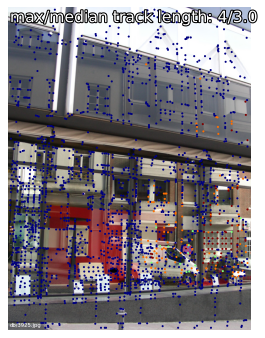

In [20]:
visualization.visualize_sfm_2d(reconstruction, images, n=1, color_by="track_length")

Color the keypoints by visibility: blue if sucessfully triangulated, red if never matched.

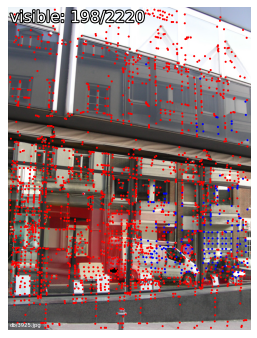

In [21]:
visualization.visualize_sfm_2d(reconstruction, images, n=1, color_by="visibility")

Color the keypoints by triangulated depth: red keypoints are far away, blue keypoints are closer.

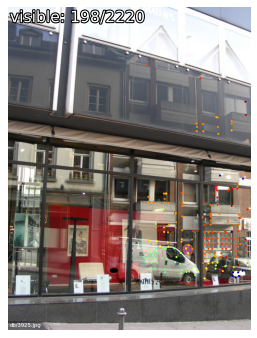

In [22]:
visualization.visualize_sfm_2d(reconstruction, images, n=1, color_by="depth")

## Visualizing the localization
We parse the localization logs and for each query image plot matches and inliers with a few database images.

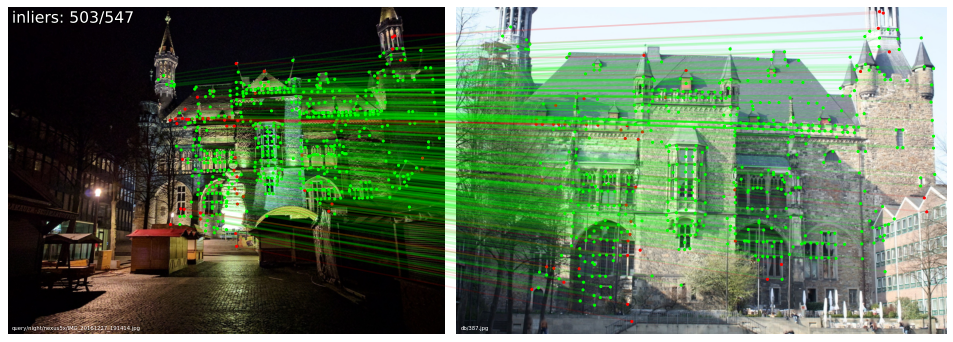

In [24]:
visualization.visualize_loc(
    results, images, reconstruction, n=1, top_k_db=1, prefix="query/night", seed=4
)